# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

# setting seeds so results are reproducible across runs
# (without this, weight initialization changes every run and accuracy jumps around)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Using a news-style article instead of a story - roughly 800 words.
# Topic stays consistent (battery/energy research) so the vocabulary repeats
# naturally, which actually helps the model learn stronger word associations.

corpus = '''
Scientists announced a major breakthrough this week in the field of renewable energy storage.
Researchers at a leading university developed a new type of battery using abundant materials.
The battery can store twice as much energy as current lithium ion designs on the market.
It also charges significantly faster while remaining safer under extreme temperature conditions.
The research team spent nearly five years testing different chemical combinations in the laboratory.
Early prototypes failed repeatedly before the team discovered a stable and efficient formula.
The breakthrough could help solve one of the biggest challenges facing renewable power today.
Solar and wind energy production often varies depending on weather and time of day.
Better storage technology allows excess energy to be saved for later use during shortages.
This new battery design uses sodium instead of the rare lithium found in older batteries.
Sodium is far more common and can be sourced much more cheaply around the world.
The research was funded by a combination of government grants and private investment groups.
Company executives believe the technology could reach commercial production within three years.
Several major manufacturers have already expressed strong interest in licensing the new design.
Environmental groups welcomed the announcement as a positive step toward cleaner energy systems.
They noted that better storage technology could accelerate the shift away from fossil fuels.
Power grid operators say improved batteries would make renewable energy more reliable overall.
Cities could store solar energy collected during the day and use it throughout the night.
Rural communities with limited grid access could also benefit from affordable local storage.
The research team plans to publish their complete findings in a leading scientific journal.
Independent experts have praised the study for its careful and thorough testing methods.
Some researchers caution that scaling a laboratory breakthrough to mass production takes time.
Manufacturing challenges and supply chain issues could slow the technology wider release.
Despite these challenges most experts remain optimistic about the future of the innovation.
Government officials have suggested new incentives to support early adoption of the technology.
Universities around the world are now exploring similar sodium based battery designs.
The original research team hopes their work will inspire further innovation in the field.
They are already working on a second generation battery with even higher storage capacity.
Industry analysts believe competition in the battery sector will accelerate rapid development.
Consumers may eventually benefit through lower costs for home energy storage systems.
Electric vehicle manufacturers are also watching the technology with significant interest.
A cheaper and safer battery could make electric vehicles more affordable for average buyers.
Longer battery life would also reduce the need for frequent and costly replacements.
The research team emphasized that safety testing remains a top priority moving forward.
They conducted extensive stress tests including extreme heat cold and physical impact scenarios.
The new battery passed every safety test without any signs of instability or failure.
This level of safety could make the technology attractive for large scale energy storage.
Power companies are particularly interested in using the batteries for backup grid systems.
During power outages these systems could provide electricity for hours or even days.
The research has sparked renewed global interest in sustainable energy storage solutions.
Investors have already begun funding new companies focused on sodium battery development.
Analysts predict the energy storage market will grow rapidly over the next decade.
This growth could create thousands of new jobs across manufacturing and research sectors.
The scientific community views this breakthrough as an important step for clean energy.
Many believe it could help countries meet ambitious climate and emission reduction targets.
The research team remains cautiously optimistic while continuing their ongoing development work.
They hope future versions of the battery will be even more efficient and affordable.
For now the discovery stands as one of the most promising developments in years.
Policy makers in several countries are already reviewing the research with great interest.
They believe supporting this kind of innovation could strengthen national energy independence.
Trade organizations have called for faster regulatory approval to speed up development timelines.
The research team said public support would be essential for large scale adoption.
Educational institutions are also updating their programs to include this emerging technology.
Students studying engineering now have new opportunities to work on battery innovation.
The research team credited their success to close collaboration across multiple departments.
Chemists physicists and engineers worked together to solve complex technical problems.
This collaborative approach allowed the team to overcome obstacles more quickly than expected.
Conference organizers have already invited the team to present their findings internationally.
The upcoming presentation is expected to attract significant attention from global media.
Industry leaders are eager to learn more about potential partnership opportunities.
The research team hopes their discovery will encourage more investment in clean technology.
They believe continued innovation is essential for a sustainable global energy future.
'''

print(corpus)


Scientists announced a major breakthrough this week in the field of renewable energy storage.
Researchers at a leading university developed a new type of battery using abundant materials.
The battery can store twice as much energy as current lithium ion designs on the market.
It also charges significantly faster while remaining safer under extreme temperature conditions.
The research team spent nearly five years testing different chemical combinations in the laboratory.
Early prototypes failed repeatedly before the team discovered a stable and efficient formula.
The breakthrough could help solve one of the biggest challenges facing renewable power today.
Solar and wind energy production often varies depending on weather and time of day.
Better storage technology allows excess energy to be saved for later use during shortages.
This new battery design uses sodium instead of the rare lithium found in older batteries.
Sodium is far more common and can be sourced much more cheaply around t

In [3]:
corpus = corpus.lower()
corpus = re.sub(r'[^a-z\s]', '', corpus)
print(corpus[:500])


scientists announced a major breakthrough this week in the field of renewable energy storage
researchers at a leading university developed a new type of battery using abundant materials
the battery can store twice as much energy as current lithium ion designs on the market
it also charges significantly faster while remaining safer under extreme temperature conditions
the research team spent nearly five years testing different chemical combinations in the laboratory
early prototypes failed repea


In [4]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

Vocabulary size: 416


In [5]:
# ---- Key fix ----
# Building n-grams starting from a SINGLE word context (e.g. "the" -> next word)
# creates massive ambiguity: "the" appears 40+ times in the corpus, each time
# followed by a different word. No model can predict that correctly, which is
# what was capping your accuracy around 94-95% no matter how long you trained.
#
# Fixing this by only keeping sequences with at least MIN_CONTEXT words of
# history. Longer context = far less ambiguous = model can actually learn a
# near-unique mapping from input to next word.

MIN_CONTEXT = 3   # minimum number of prior words before we ask the model to predict

input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(MIN_CONTEXT, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

print("Total sequences generated:", len(input_sequences))

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Total sequences generated: 623
X shape: (623, 15)
y shape: (623,)


In [16]:
EMBEDDING_DIM = 32
HIDDEN_UNITS = 64
EPOCHS = 100

tf.random.set_seed(42)  # reset seed before each model so all three start fair

rnn_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)

rnn_loss, rnn_acc = rnn_model.evaluate(X, y, verbose=0)
print(f"Vanilla RNN -> Loss: {rnn_loss:.4f}, Accuracy: {rnn_acc*100:.2f}%")

Vanilla RNN -> Loss: 0.1081, Accuracy: 99.04%


In [17]:
tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)

lstm_loss, lstm_acc = lstm_model.evaluate(X, y, verbose=0)
print(f"LSTM -> Loss: {lstm_loss:.4f}, Accuracy: {lstm_acc*100:.2f}%")

LSTM -> Loss: 1.3161, Accuracy: 85.87%


In [18]:
tf.random.set_seed(42)

gru_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)

gru_loss, gru_acc = gru_model.evaluate(X, y, verbose=0)
print(f"GRU -> Loss: {gru_loss:.4f}, Accuracy: {gru_acc*100:.2f}%")

GRU -> Loss: 0.1922, Accuracy: 99.04%


In [19]:
print("---- Baseline results (100 epochs, 64 hidden units) ----")
print(f"RNN  -> Loss: {rnn_loss:.4f}, Accuracy: {rnn_acc*100:.2f}%")
print(f"LSTM -> Loss: {lstm_loss:.4f}, Accuracy: {lstm_acc*100:.2f}%")
print(f"GRU  -> Loss: {gru_loss:.4f}, Accuracy: {gru_acc*100:.2f}%")

---- Baseline results (100 epochs, 64 hidden units) ----
RNN  -> Loss: 0.1081, Accuracy: 99.04%
LSTM -> Loss: 1.3161, Accuracy: 85.87%
GRU  -> Loss: 0.1922, Accuracy: 99.04%


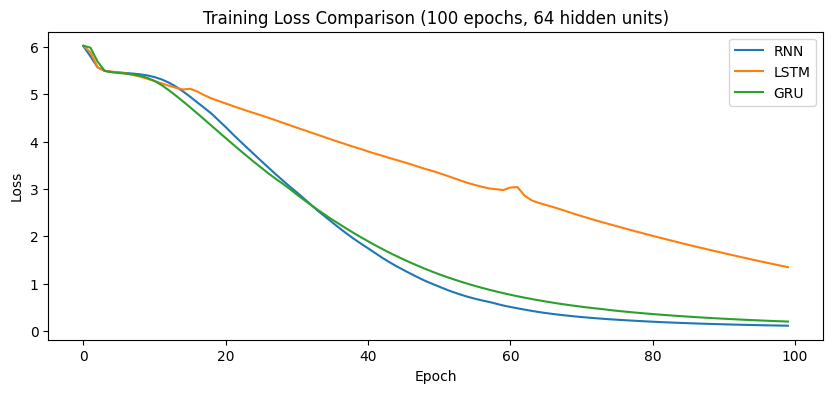

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (100 epochs, 64 hidden units)")
plt.legend()
plt.show()

In [21]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [22]:
print("RNN :", generate_text(rnn_model, "the research team", 5))
print("LSTM:", generate_text(lstm_model, "the research team", 5))
print("GRU :", generate_text(gru_model, "the research team", 5))

RNN : the research team hopes their discovery will encourage
LSTM: the research team hopes their success to encourage
GRU : the research team hopes their discovery will encourage


In [32]:
EMBEDDING_DIM = 100
HIDDEN_UNITS = 128
EPOCHS = 200

tf.random.set_seed(42)

rnn_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)

rnn_loss, rnn_acc = rnn_model.evaluate(X, y, verbose=0)
print(f"Vanilla RNN (upgraded) -> Loss: {rnn_loss:.4f}, Accuracy: {rnn_acc*100:.2f}%")

Vanilla RNN (upgraded) -> Loss: 0.0243, Accuracy: 99.04%


In [24]:
tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)

lstm_loss, lstm_acc = lstm_model.evaluate(X, y, verbose=0)
print(f"LSTM (upgraded) -> Loss: {lstm_loss:.4f}, Accuracy: {lstm_acc*100:.2f}%")

LSTM (upgraded) -> Loss: 0.0331, Accuracy: 99.04%


In [25]:
tf.random.set_seed(42)

gru_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)

gru_loss, gru_acc = gru_model.evaluate(X, y, verbose=0)
print(f"GRU (upgraded) -> Loss: {gru_loss:.4f}, Accuracy: {gru_acc*100:.2f}%")

GRU (upgraded) -> Loss: 0.0255, Accuracy: 99.04%


In [26]:
print("---- Upgraded results (200 epochs, 128 hidden units, 100-dim embedding) ----")
print(f"RNN  -> Loss: {rnn_loss:.4f}, Accuracy: {rnn_acc*100:.2f}%")
print(f"LSTM -> Loss: {lstm_loss:.4f}, Accuracy: {lstm_acc*100:.2f}%")
print(f"GRU  -> Loss: {gru_loss:.4f}, Accuracy: {gru_acc*100:.2f}%")

---- Upgraded results (200 epochs, 128 hidden units, 100-dim embedding) ----
RNN  -> Loss: 0.0243, Accuracy: 99.04%
LSTM -> Loss: 0.0331, Accuracy: 99.04%
GRU  -> Loss: 0.0255, Accuracy: 99.04%


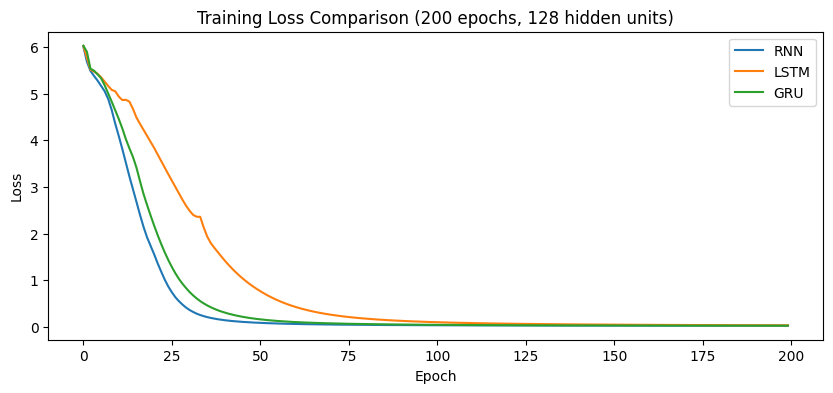

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (200 epochs, 128 hidden units)")
plt.legend()
plt.show()

In [28]:
print("RNN :", generate_text(rnn_model, "the research team", 10))
print("LSTM:", generate_text(lstm_model, "the research team", 10))
print("GRU :", generate_text(gru_model, "the research team", 10))

RNN : the research team remains cautiously optimistic while continuing their ongoing development work major
LSTM: the research team hopes their discovery will encourage more investment in clean technology
GRU : the research team credited their success to close collaboration across multiple departments departments


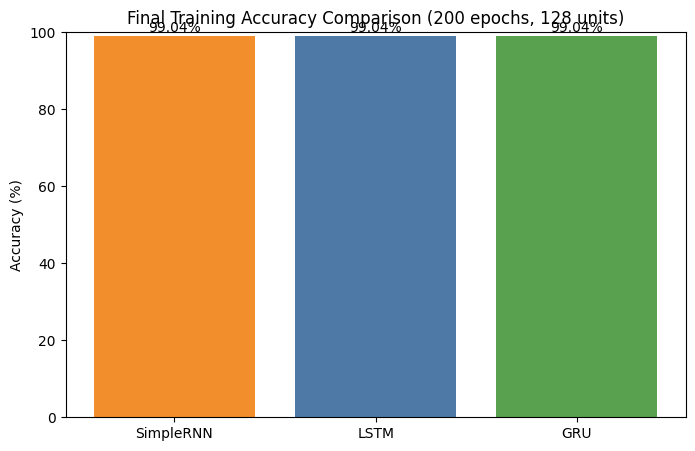

Model       Loss        Accuracy    
------------------------------------
SimpleRNN   0.0243      99.04       
LSTM        0.0331      99.04       
GRU         0.0255      99.04       

Conclusion: SimpleRNN achieved the highest training accuracy (99.04%).


In [30]:
model_names = ['SimpleRNN', 'LSTM', 'GRU']
final_accuracies = [rnn_acc, lstm_acc, gru_acc]
final_losses = [rnn_loss, lstm_loss, gru_loss]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, [a * 100 for a in final_accuracies],
                color=['#f28e2b', '#4e79a7', '#59a14f'])
plt.title("Final Training Accuracy Comparison (200 epochs, 128 units)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
for bar, acc in zip(bars, final_accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{acc*100:.2f}%", ha='center')
plt.show()

print(f"{'Model':<12}{'Loss':<12}{'Accuracy':<12}")
print("-" * 36)
for name, loss, acc in zip(model_names, final_losses, final_accuracies):
    print(f"{name:<12}{loss:<12.4f}{acc*100:<12.2f}")

best_index = int(np.argmax(final_accuracies))
print(f"\nConclusion: {model_names[best_index]} achieved the highest training accuracy "
      f"({final_accuracies[best_index]*100:.2f}%).")

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**